In [1]:
import pandas as pd 
import numpy as np
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gaussian_kde

In [8]:
def insert_missing_openers_safely(df):
    df = df.reset_index(drop=True).copy()
    if 'was_inserted' not in df.columns:
        df['was_inserted'] = False  # Initialize the flag

    new_rows = []
    stack = []
    event_col = 'events'

    for i, val in enumerate(df[event_col]):
        if val in [1.0, 2.0]:
            stack.append((val, i))  # Opener

        elif val in [-1.0, -2.0]:
            if stack:
                last_val, _ = stack[-1]
                if last_val + val == 0:
                    stack.pop()
                    continue

            # No opener → create a duplicate row with flipped event and tag as inserted
            new_row = df.iloc[i].copy()
            new_row[event_col] = abs(val)
            new_row['was_inserted'] = True
            new_rows.append((i, new_row))

    for offset, (idx, row) in enumerate(new_rows):
        df = pd.concat([
            df.iloc[:idx + offset],
            pd.DataFrame([row]),
            df.iloc[idx + offset:]
        ], ignore_index=True)

    return df

In [9]:
def insert_missing_openers_grouped(df):
    grouped = df.groupby(['SubjectID', 'Session', 'SessionSubsection'], sort=False)
    
    fixed_chunks = []
    for _, group in tqdm(grouped, total=grouped.ngroups, desc="Inserting missing openers"):
        group_sorted = group.sort_values('timeStampDataPointEnd')  # Or your preferred timestamp column
        fixed_group = insert_missing_openers_safely(group_sorted)
        fixed_chunks.append(fixed_group)
    
    return pd.concat(fixed_chunks, ignore_index=True)


In [3]:
df_validData = pd.read_csv("/Volumes/TwoTeras/0_Experiment_1/Eye_Tracking/Pre_processed/Data_Sets/Complete_Data_AngularV.cvs")

In [4]:
df_validData.head()

,Unnamed: 0,index,SubjectID,Session,SessionSubsection,timeStampDataPointEnd,eyeOpennessLeft,eyeOpennessRight,pupilDiameterMillimetersLeft,pupilDiameterMillimetersRight,...,thresh,isFix,corrected_vel,events,length,distance,avg_dist,names,Collider_CategoricalN,Unnamed: 0.2
0,0,0,365,1,1,1.635519e+09,1.0,1.0,3.333588,3.785751,...,44.460563,NaN,NaN,NaN,NaN,NaN,NaN,Building_161,Building,NaN
1,1,1,365,1,1,1.635519e+09,1.0,1.0,3.291748,3.744843,...,44.460563,0.000000,NaN,2.0,0.672079,63.996796,63.996938,Building_161,Building,NaN
2,2,2,365,1,1,1.635519e+09,1.0,1.0,3.291748,3.744843,...,44.460563,0.000000,NaN,NaN,0.672079,63.996796,63.996938,Building_161,Building,NaN
3,3,3,365,1,1,1.635519e+09,1.0,1.0,3.259613,3.707169,...,44.460563,73.369491,NaN,NaN,0.672079,63.997106,63.996938,Building_161,Building,NaN
4,4,4,365,1,1,1.635519e+09,1.0,1.0,3.259613,3.707169,...,44.460563,0.642210,0.64221,NaN,0.672079,63.997107,63.996938,Building_161,Building,NaN


In [6]:
columns_to_drop = [
    'Unnamed: 0', 'index',
    'handLeftPosition.x', 'handLeftPosition.y', 'handLeftPosition.z',
    'handLeftRotation.x', 'handLeftRotation.y', 'handLeftRotation.z',
    'handLeftScale.x', 'handLeftScale.y', 'handLeftScale.z',
    'handLeftDirectionForward.x', 'handLeftDirectionForward.y', 'handLeftDirectionForward.z',
    'handLeftDirectionRight.x', 'handLeftDirectionRight.y', 'handLeftDirectionRight.z',
    'handLeftDirectionUp.x', 'handLeftDirectionUp.y', 'handLeftDirectionUp.z',
    'handRightPosition.x', 'handRightPosition.y', 'handRightPosition.z',
    'handRightRotation.x', 'handRightRotation.y', 'handRightRotation.z',
    'handRightScale.x', 'handRightScale.y', 'handRightScale.z',
    'handRightDirectionForward.x', 'handRightDirectionForward.y', 'handRightDirectionForward.z',
    'handRightDirectionRight.x', 'handRightDirectionRight.y', 'handRightDirectionRight.z',
    'handRightDirectionUp.x', 'handRightDirectionUp.y', 'handRightDirectionUp.z',
    'ordinalOfHit', 'Continuous_Time' , 'Unnamed: 0.2',
]

# Drop only if columns exist
df_validData_small = df_validData.drop(columns=[col for col in columns_to_drop if col in df_validData.columns])

In [10]:
fixed_df_complete = insert_missing_openers_grouped(df_validData_small)

Inserting missing openers: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [07:06<00:00,  1.02s/it]


In [11]:
# Collider list
collider_list = [
    '56_Sa', '39_Sa', '19_Cma', '55_Sa', '25_Cma', '40_Sa', '41_Sa',
    '17_Cma', '47_Sa', '03_Cma', '13_Cma', '24_Cma', '01_Cma', '54_Sa',
    '15_Cma', '29_Sa', '04_Cma', '49_Sa', '30_Sa', '02_Cma', '51_Sa',
    '08_Cma', '28_Cma', '26_Cma', '44_Sa', '06_Cma', '53_Sa', '37_Sa',
    '32_Sa', '20_Cma', '16_Cma', '50_Sa', '34_Sa', '11_Cma', '38_Sa',
    '33_Sa', '12_Cma', '22_Cma', '42_Sa', '05_Cma', '23_Cma', '18_Cma',
    '27_Cma', '45_Sa', '43_Sa', '09_Cma', '31_Sa', '48_Sa', '10_Cma',
    '52_Sa', '07_Cma', '46_Sa', '35_Sa', '36_Sa', '21_Cma', '14_Cma'
]


In [12]:
# Define window sizes (adjust as needed)
pre_window = pd.Timedelta(seconds=30)
post_window = pd.Timedelta(seconds=15)
during_window = pd.Timedelta(seconds=15)  # optional "during" window

# Store all trial slices
all_trials = []

# Group by participant/session/session subsection
grouped = fixed_df_complete.groupby(['SubjectID', 'Session', 'SessionSubsection'])

for (subj, sess, subsection), group in tqdm(grouped, desc="Processing Groups"):
    group = group.copy()
    group['date_seconds'] = pd.to_datetime(group['timeStampDataPointEnd'], unit='s')
    
    # Filter agent encounter events
    filtered_df = group[group['events'] == 2].copy() # Beggining of fixation
    filtered_df = filtered_df[filtered_df['names'].isin(collider_list)]

    filtered_df['Occurrence_Order'] = filtered_df.groupby('names').cumcount() + 1

    last_processed_time = {}
    
    for idx, row in filtered_df.iterrows():
        collider = row['names']
        event_time = row['date_seconds']
        
        # Skip duplicates within 30 seconds
        if (
            collider in last_processed_time 
            and (event_time - last_processed_time[collider]).total_seconds() <= 30
        ):
            continue

        last_processed_time[collider] = event_time
        
        # Define windows
        pre_start = max(group['date_seconds'].min(), event_time - pre_window)
        pre_end = event_time
        post_start = event_time
        post_end = min(group['date_seconds'].max(), event_time + post_window)

        trial_id = f"{collider}_{subj}_{sess}_{subsection}_Trial_{row['Occurrence_Order']}"

        # Extract slices and tag
        pre_df = group[(group['date_seconds'] >= pre_start) & (group['date_seconds'] < pre_end)].copy()
        post_df = group[(group['date_seconds'] > post_start) & (group['date_seconds'] <= post_end)].copy()

        pre_df['Pre_Post'] = 'Pre'
        post_df['Pre_Post'] = 'Post'

        # Optional: during window in the middle
        during_df = group[
            (group['date_seconds'] >= event_time) &
            (group['date_seconds'] <= event_time + during_window)
        ].copy()
        during_df['Pre_Post'] = 'During'

        # Add trial and metadata
        for df in [pre_df, during_df, post_df]:
            df['Trial_ID'] = trial_id
            df['Collider_Name'] = collider
            df['Occurrence_Order'] = row['Occurrence_Order']
            df['Event_Time'] = event_time
            df['SubjectID'] = subj
            df['Session'] = sess
            df['SessionSubsection'] = subsection

        all_trials.extend([pre_df, during_df, post_df])

# Combine all trial slices
if all_trials:
    trials_long_df = pd.concat(all_trials, ignore_index=True)
else:
    trials_long_df = pd.DataFrame()


Processing Groups: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:38<00:00, 10.82it/s]


In [13]:
trials_long_df.head()

,SubjectID,Session,SessionSubsection,timeStampDataPointEnd,eyeOpennessLeft,eyeOpennessRight,pupilDiameterMillimetersLeft,pupilDiameterMillimetersRight,leftGazeValidityBitmask,rightGazeValidityBitmask,...,avg_dist,names,Collider_CategoricalN,was_inserted,date_seconds,Pre_Post,Trial_ID,Collider_Name,Occurrence_Order,Event_Time
0,365,1,1,1.635519e+09,1.0,1.0,3.333588,3.785751,31,31,...,NaN,Building_161,Building,False,2021-10-29 14:55:46.468227625,Pre,46_Sa_365_1_1_Trial_1,46_Sa,1,2021-10-29 14:56:01.897292376
1,365,1,1,1.635519e+09,1.0,1.0,3.291748,3.744843,31,31,...,63.996938,Building_161,Building,False,2021-10-29 14:55:46.476162910,Pre,46_Sa_365_1_1_Trial_1,46_Sa,1,2021-10-29 14:56:01.897292376
2,365,1,1,1.635519e+09,1.0,1.0,3.291748,3.744843,31,31,...,63.996938,Building_161,Building,False,2021-10-29 14:55:46.484594345,Pre,46_Sa_365_1_1_Trial_1,46_Sa,1,2021-10-29 14:56:01.897292376
3,365,1,1,1.635519e+09,1.0,1.0,3.259613,3.707169,31,31,...,63.996938,Building_161,Building,False,2021-10-29 14:55:46.493522644,Pre,46_Sa_365_1_1_Trial_1,46_Sa,1,2021-10-29 14:56:01.897292376
4,365,1,1,1.635519e+09,1.0,1.0,3.259613,3.707169,31,31,...,63.996938,Building_161,Building,False,2021-10-29 14:55:46.504436016,Pre,46_Sa_365_1_1_Trial_1,46_Sa,1,2021-10-29 14:56:01.897292376


In [ ]:
# Count trials per Subject × Session ---
trial_counts = (
    trials_long_df
    .groupby(['SubjectID', 'Session'])['Trial_ID']
    .nunique()
    .unstack(fill_value=0)  # shape: subjects × sessions
)


In [ ]:
# Keep only subjects with >0 in ALL sessions ---
valid_subjects = trial_counts[(trial_counts > 0).all(axis=1)].index.tolist()


In [ ]:
filtered_trials_long_df = trials_long_df[trials_long_df['SubjectID'].isin(valid_subjects)].copy()

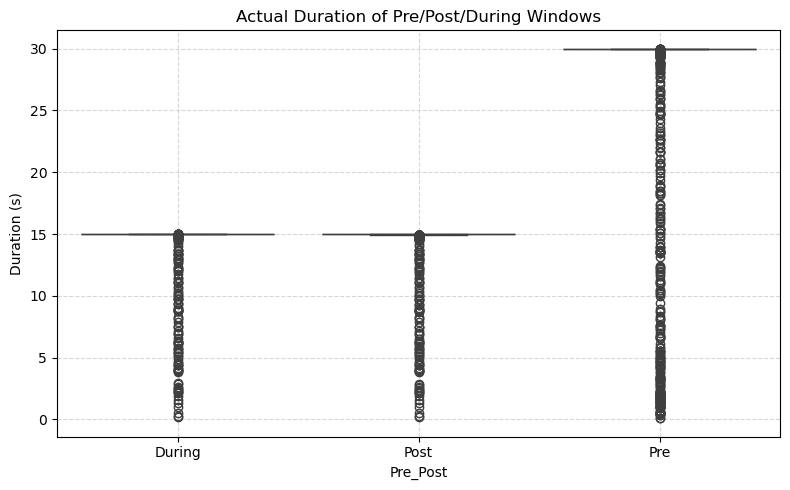

In [15]:
# sanity check 1: Actual window sizes
duration_df = filtered_trials_long_df.groupby(['Trial_ID', 'Pre_Post'])['timeStampDataPointEnd'].agg(['min', 'max']).reset_index()
duration_df['Duration_s'] = duration_df['max'] - duration_df['min']

plt.figure(figsize=(8, 5))
sns.boxplot(data=duration_df, x='Pre_Post', y='Duration_s')
plt.title("Actual Duration of Pre/Post/During Windows")
plt.ylabel("Duration (s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


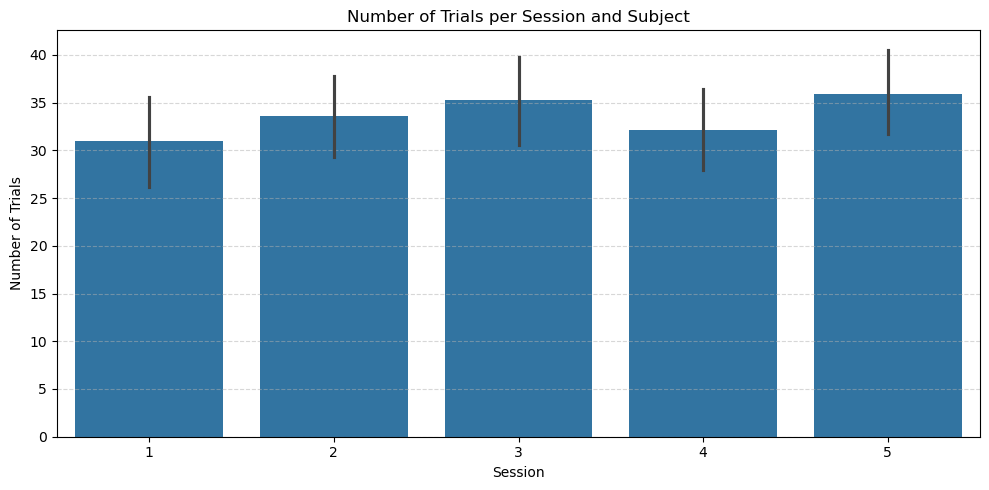

In [16]:
# --- Step 1: Count unique trials per subject and session ---
trial_counts = (
    filtered_trials_long_df
    .groupby(['SubjectID', 'Session'])['Trial_ID']
    .nunique()
    .reset_index(name='n_trials')
)

# --- Step 2: Plot ---
plt.figure(figsize=(10, 5))
sns.barplot(data=trial_counts, x='Session', y='n_trials')
plt.title("Number of Trials per Session and Subject")
plt.ylabel("Number of Trials")
plt.xlabel("Session")
plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.legend(title='Subject', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


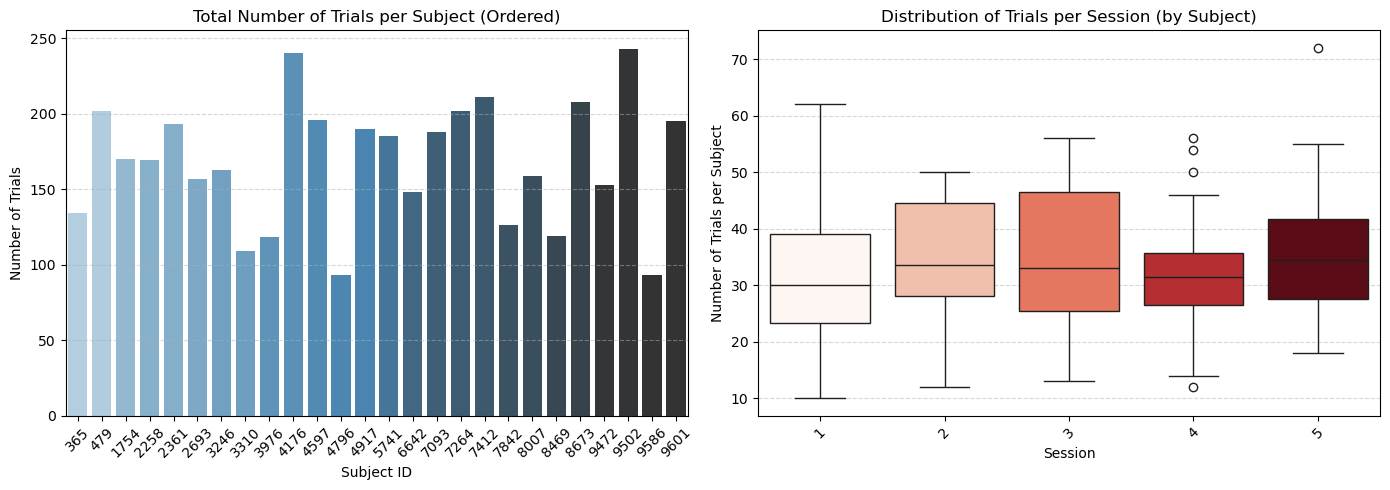

In [18]:
# --- Step 1: Count trials per subject-session ---
per_subject_session = (
    filtered_trials_long_df.groupby(['SubjectID', 'Session'])['Trial_ID']
    .nunique()
    .reset_index(name='n_windows')
)

# --- Step 2: Count total trials per subject and sort ---
trials_per_subject = (
    filtered_trials_long_df.groupby('SubjectID')['Trial_ID']
    .nunique()
    .reset_index(name='n_windows')
    .sort_values('n_windows')  # sort by ascending trial count
)

# Extract sorted subject order
subject_order = filtered_trials_long_df["SubjectID"].tolist()

# --- Step 3: Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Left plot: Barplot per subject (ordered, warning-free) ---
sns.barplot(
    data=trials_per_subject,
    x='SubjectID',
    y='n_windows',
    hue='SubjectID',         # fix future warning
    palette='Blues_d',
    legend=False,
    order=subject_order,     # enforce order
    ax=axes[0]
)
axes[0].set_title("Total Number of Trials per Subject (Ordered)")
axes[0].set_ylabel("Number of Trials")
axes[0].set_xlabel("Subject ID")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Right plot: Boxplot per session (warning-free) ---
sns.boxplot(
    data=per_subject_session,
    x='Session',
    y='n_windows',
    hue='Session',
    palette='Reds',
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribution of Trials per Session (by Subject)")
axes[1].set_ylabel("Number of Trials per Subject")
axes[1].set_xlabel("Session")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [19]:
# --- Step 4: Count trials per Subject × Session (for heatmap) ---
trials_per_subject_session = (
    filtered_trials_long_df.groupby(['SubjectID', 'Session'])['Trial_ID']
    .nunique()
    .reset_index(name='n_trials')
)

# Pivot table for heatmap
heatmap_data = trials_per_subject_session.pivot(
    index='SubjectID',
    columns='Session',
    values='n_trials'
).fillna(0)

# Sort rows by total trials (optional for consistency with barplot)
heatmap_data = heatmap_data.loc[subject_order]

In [ ]:
# --- Step 5: Plotting all three ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 1, 1.2]})

# --- Plot 1: Barplot per Subject ---
sns.barplot(
    data=trials_per_subject,
    x='SubjectID',
    y='n_windows',
    hue='SubjectID',
    palette='Blues_d',
    legend=False,
    order=subject_order,
    ax=axes[0]
)
axes[0].set_title("Total Number of Trials per Subject")
axes[0].set_ylabel("Number of Trials")
axes[0].set_xlabel("Subject ID")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Boxplot per Session ---
sns.boxplot(
    data=per_subject_session,
    x='Session',
    y='n_windows',
    hue='Session',
    palette='Reds',
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribution of Trials per Session")
axes[1].set_ylabel("Number of Trials per Subject")
axes[1].set_xlabel("Session")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 3: Heatmap Subject × Session ---
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of Trials'},
    ax=axes[2]
)
axes[2].set_title("Trials per Subject × Session")
axes[2].set_xlabel("Session")
axes[2].set_ylabel("Subject ID")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Ensure correct datetime format (in case it's not already)
filtered_trials_long_df['Event_Time'] = pd.to_datetime(filtered_trials_long_df['Event_Time'])

# Sort by Subject, Session, Subsection, and Event Time
filtered_trials_long_df.sort_values(
    by=['SubjectID', 'Session', 'SessionSubsection', 'Event_Time'],
    inplace=True
)

# Optional: reset index
filtered_trials_long_df.reset_index(drop=True, inplace=True)

In [ ]:
filtered_trials_long_df.tail(2200)

In [ ]:
# Create a copy of the original column with updated labels
filtered_trials_long_df["Pre_Post_Collapsed"] = filtered_trials_long_df["Pre_Post"].replace({"During": "Post"})


In [ ]:
filtered_trials_long_df.Occurrence_Order.describe()

In [ ]:
filtered_trials_long_df.head()

In [ ]:
# Filter out negative values first
df_valid = filtered_trials_long_df[
    (filtered_trials_long_df['pupilDiameterMillimetersRight'] >= 0) &
    (filtered_trials_long_df['pupilDiameterMillimetersLeft'] >= 0)
]

# List to hold all summaries
summary_data = []

# Group by Subject, Pre_Post, and optionally Session/Subsection if needed
grouped = df_valid.groupby(['SubjectID', 'Pre_Post_Collapsed'])

for (subject, Pre_Post_Collapsed), df_subj in grouped:
    # Right eye
    q1_r = np.nanquantile(df_subj.pupilDiameterMillimetersRight, 0.25)
    med_r = np.nanmedian(df_subj.pupilDiameterMillimetersRight)
    q3_r = np.nanquantile(df_subj.pupilDiameterMillimetersRight, 0.75)
    iqr_r = q3_r - q1_r
    bowley_r = (q3_r + q1_r - 2 * med_r) / iqr_r if iqr_r != 0 else np.nan
    mean_r = np.nanmean(df_subj.pupilDiameterMillimetersRight)
    sd_r = np.nanstd(df_subj.pupilDiameterMillimetersRight)
    max_r = np.nanmax(df_subj.pupilDiameterMillimetersRight)
    min_r = np.nanmin(df_subj.pupilDiameterMillimetersRight)

    # Left eye
    q1_l = np.nanquantile(df_subj.pupilDiameterMillimetersLeft, 0.25)
    med_l = np.nanmedian(df_subj.pupilDiameterMillimetersLeft)
    q3_l = np.nanquantile(df_subj.pupilDiameterMillimetersLeft, 0.75)
    iqr_l = q3_l - q1_l
    bowley_l = (q3_l + q1_l - 2 * med_l) / iqr_l if iqr_l != 0 else np.nan
    mean_l = np.nanmean(df_subj.pupilDiameterMillimetersLeft)
    sd_l = np.nanstd(df_subj.pupilDiameterMillimetersLeft)
    max_l = np.nanmax(df_subj.pupilDiameterMillimetersLeft)
    min_l = np.nanmin(df_subj.pupilDiameterMillimetersLeft)

    summary_data.append({
        'SubjectID': subject,
        'Pre_Post_Collapsed': Pre_Post_Collapsed,
        
        'pd_r_mm_min': min_r,
        'pd_r_mm_max': max_r,
        'pd_r_mm_mean': mean_r,
        'pd_r_mm_sd': sd_r,
        'pd_r_mm_med': med_r,
        'pd_r_mm_DistQ1-Q3': iqr_r,
        'pd_r_mm_bowleyCoef': bowley_r,

        'pd_l_mm_min': min_l,
        'pd_l_mm_max': max_l,
        'pd_l_mm_mean': mean_l,
        'pd_l_mm_sd': sd_l,
        'pd_l_mm_med': med_l,
        'pd_l_mm_DistQ1-Q3': iqr_l,
        'pd_l_mm_bowleyCoef': bowley_l
    })

# Create the summary DataFrame
df_pupilD_by_window = pd.DataFrame(summary_data)

# Optional: sort by Subject and Pre_Post order
pre_post_order = {'Pre': 0, 'Post': 1}
df_pupilD_by_window['Pre_Post_order'] = df_pupilD_by_window['Pre_Post_Collapsed'].map(pre_post_order)
df_pupilD_by_window.sort_values(['SubjectID', 'Pre_Post_order'], inplace=True)
df_pupilD_by_window.drop(columns='Pre_Post_order', inplace=True)

# Final result
df_pupilD_by_window


In [ ]:
df_pupilD_by_window.head()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# --- Step 1: Melt and clean data ---
df_melted = pd.melt(
    df_pupilD_by_window,
    id_vars=['SubjectID', 'Pre_Post_Collapsed'],
    value_vars=['pd_r_mm_med', 'pd_l_mm_med'],
    var_name='Eye',
    value_name='Median_Pupil_Diameter'
)

df_melted['Eye'] = df_melted['Eye'].map({
    'pd_r_mm_med': 'Right Eye',
    'pd_l_mm_med': 'Left Eye'
})

df_melted['Eye'] = df_melted['Eye'].astype(str)
df_melted['Pre_Post_Collapsed'] = df_melted['Pre_Post_Collapsed'].astype(str)
df_melted['Median_Pupil_Diameter'] = pd.to_numeric(df_melted['Median_Pupil_Diameter'], errors='coerce')
df_melted_clean = df_melted.dropna(subset=["Median_Pupil_Diameter"])

# --- Step 2: Setup plot layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex='col')

# --- Step 3: Define red–blue palette ---

full_palette = sns.color_palette("RdBu", n_colors=4)
unique_groups = sorted(df_melted_clean["Pre_Post_Collapsed"].unique())

# Assign first and last colors (deep blue and deep red)
group_colors = {
    unique_groups[0]: full_palette[0],   # Deep blue
    unique_groups[-1]: full_palette[-1]  # Deep red
}

# --- Step 4: Top row – KDEs with area under curve ---
for i, eye in enumerate(["Right Eye", "Left Eye"]):
    ax = axes[0, i]
    eye_data = df_melted_clean[df_melted_clean["Eye"] == eye]

    for group in unique_groups:
        subset = eye_data[eye_data["Pre_Post_Collapsed"] == group]["Median_Pupil_Diameter"].dropna()
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)

        std = subset.std()
        x_min = subset.min()
        x_max = subset.max()
        x_vals = np.linspace(x_min, x_max, 500)
        y_vals = kde(x_vals)

        area = np.trapz(y_vals, x_vals)
        print(f"[{eye} | {group}] Area under KDE curve: {area:.4f}")

        ax.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

    ax.set_title(f"{eye} – KDE")
    ax.set_xlabel("")
    ax.set_ylabel("Density" if i == 0 else "")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

# --- Step 5: Bottom row – Horizontal boxplots ---
for i, eye in enumerate(["Right Eye", "Left Eye"]):
    ax = axes[1, i]
    eye_data = df_melted_clean[df_melted_clean["Eye"] == eye]

    sns.boxplot(
        data=eye_data,
        y="Pre_Post_Collapsed",
        x="Median_Pupil_Diameter",
        orient="h",
        hue="Pre_Post_Collapsed",
        palette=group_colors,
        dodge=False,
        legend=False,
        ax=ax
    )
    ax.set_title(f"{eye} – Box Plot")
    ax.set_xlabel("Pupil Diameter (mm)")
    ax.set_ylabel("Time Window")
    ax.grid(True, linestyle='--', alpha=0.4)

# --- Step 6: Layout adjustment ---
plt.tight_layout()
plt.show()


In [ ]:
df_pupilD_by_window.to_csv("/Volumes/TwoTeras/PCA/Data_Sets/Experiment_1/df_pupilD_by_window.csv", index=False)

In [ ]:
# Step 1: Filter fixations (as before)
fixations = filtered_trials_long_df[filtered_trials_long_df.events == 2]

# Step 2: Count number of fixations per subject × condition
n_fix_df = (
    fixations
    .groupby(['SubjectID', 'Pre_Post_Collapsed'])
    .size()
    .reset_index(name='NFix')
    .astype({'SubjectID': str})
)

# Step 3: Count number of unique trials per subject × condition
n_trials_df = (
    fixations
    .groupby(['SubjectID', 'Pre_Post_Collapsed'])['Trial_ID']
    .nunique()
    .reset_index(name='NTrials')
    .astype({'SubjectID': str})
)

# Step 4: Merge and normalize
n_fix_df = pd.merge(n_fix_df, n_trials_df, on=['SubjectID', 'Pre_Post_Collapsed'])
n_fix_df['Fixations_per_Trial'] = n_fix_df['NFix'] / n_fix_df['NTrials']


In [ ]:
fixations.head()

In [ ]:


# --- Step 1: Clean data ---
df_clean = n_fix_df.dropna(subset=["NFix", "Pre_Post_Collapsed"])

# --- Step 2: Setup layout ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Step 3: KDEs (tight edges) ---
ax_kde = axes[0]
unique_groups = sorted(df_clean['Pre_Post_Collapsed'].unique())

for group in unique_groups:
    subset = df_clean[df_clean['Pre_Post_Collapsed'] == group]['NFix'].dropna()
    if len(subset) < 2:
        continue  # skip if not enough data

    # KDE
    kde = gaussian_kde(subset)

    # Tight range: just observed min/max
    x_vals = np.linspace(subset.min(), subset.max(), 500)
    y_vals = kde(x_vals)

    # Area under KDE curve
    area = np.trapz(y_vals, x_vals)
    print(f"[{group}] Area under KDE curve: {area:.4f}")

    ax_kde.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

ax_kde.set_title("KDE of Number of Total Fixations")
ax_kde.set_ylabel("Density")
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.5)

# --- Step 4: Horizontal boxplot ---
ax_box = axes[1]
sns.boxplot(
    data=df_clean,
    y="Pre_Post_Collapsed",
    x="NFix",
    orient="h",
    hue="Pre_Post_Collapsed",
    palette=group_colors,
    dodge=False,
    legend=False,
    ax=ax_box
)
ax_box.set_title("Horizontal Boxplot of Fixations per Group")
ax_box.set_xlabel("Number of Fixations")
ax_box.set_ylabel("Time Window")
ax_box.grid(True, linestyle='--', alpha=0.5)

# --- Step 5: Final layout ---
plt.tight_layout()
plt.show()


In [ ]:
# --- Step 1: Clean data ---
df_clean = n_fix_df.dropna(subset=["Fixations_per_Trial", "Pre_Post_Collapsed"])

# --- Step 2: Setup layout ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Step 3: KDEs (tight edges) ---
ax_kde = axes[0]
unique_groups = sorted(df_clean['Pre_Post_Collapsed'].unique())

for group in unique_groups:
    subset = df_clean[df_clean['Pre_Post_Collapsed'] == group]['Fixations_per_Trial'].dropna()
    if len(subset) < 2:
        continue  # skip if not enough data

    kde = gaussian_kde(subset)
    x_vals = np.linspace(subset.min(), subset.max(), 500)
    y_vals = kde(x_vals)

    area = np.trapz(y_vals, x_vals)
    print(f"[{group}] Area under KDE curve: {area:.4f}")

    ax_kde.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

ax_kde.set_title("KDE of Fixations per encounter")
ax_kde.set_ylabel("Density")
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.5)

# --- Step 4: Horizontal boxplot ---
ax_box = axes[1]
sns.boxplot(
    data=df_clean,
    y="Pre_Post_Collapsed",
    x="Fixations_per_Trial",
    orient="h",
    hue="Pre_Post_Collapsed",
    palette=group_colors,
    dodge=False,
    legend=False,
    ax=ax_box
)
ax_box.set_title("Horizontal Boxplot of Fixations per encounter")
ax_box.set_xlabel("Fixations per encounter")
ax_box.set_ylabel("Time Window")
ax_box.grid(True, linestyle='--', alpha=0.5)

# --- Step 5: Final layout ---
plt.tight_layout()
plt.show()


In [ ]:
n_fix_df.head()

In [ ]:
n_fix_df.to_csv("/Volumes/TwoTeras/PCA/Data_Sets/Experiment_1/n_fix_df_window.csv", index=False)

In [ ]:
# Step 1: Pivot to get Pre and Post as columns
df_diff = (
    n_fix_df.pivot(index='SubjectID', columns='Pre_Post_Collapsed', values='NFix')
    .dropna(subset=['Pre', 'Post'])  # make sure both values are present
    .reset_index()
)

# Step 2: Calculate the difference
df_diff['Post_minus_Pre'] = df_diff['Post'] - df_diff['Pre']

# Final result
df_diff[['SubjectID', 'Post', 'Pre', 'Post_minus_Pre']]


In [ ]:
# Step 1: Ensure datetime is available
filtered_trials_long_df['datetime'] = pd.to_datetime(filtered_trials_long_df['timeStampDataPointEnd'], unit='s')

Fixations_Windowed = filtered_trials_long_df[filtered_trials_long_df.events == 2] 
# Step 2: Group by subject/session/subsection + collapsed window
grouped = Fixations_Windowed.groupby(['SubjectID', 'Session', 'SessionSubsection', 'Pre_Post_Collapsed'])

# Step 3: Aggregate counts and times
fixation_rates = (
    grouped
    .agg(
        n_fixations=('datetime', 'count'),
        start_time=('datetime', 'min'),
        end_time=('datetime', 'max')
    )
    .reset_index()
)

# Step 4: Compute duration and rate
fixation_rates['duration_seconds'] = (fixation_rates['end_time'] - fixation_rates['start_time']).dt.total_seconds()
fixation_rates['fixations_per_second'] = fixation_rates['n_fixations'] / fixation_rates['duration_seconds']

# Final tidy output
fixation_rates = fixation_rates[['SubjectID', 'Session', 'SessionSubsection', 'Pre_Post_Collapsed', 'fixations_per_second']]


In [ ]:
# Split the data
pre_data = fixation_rates[fixation_rates['Pre_Post_Collapsed'] == 'Pre']['fixations_per_second'].dropna()
post_data = fixation_rates[fixation_rates['Pre_Post_Collapsed'] == 'Post']['fixations_per_second'].dropna()

# Define group data and labels
group_data = {'Pre': pre_data, 'Post': post_data}
colors = {'Pre': 'tab:orange', 'Post': 'tab:blue'}

# Start plot
plt.figure(figsize=(8, 5))

# Loop through groups
for label, data in group_data.items():
    # Histogram (use raw counts)
    bin_edges = np.linspace(data.min() - 1, data.max() + 1, 40)
    counts, bins, _ = plt.hist(data, bins=bin_edges, density=False, alpha=0.3,
                                edgecolor='black', label=f'{label} Histogram', color=colors[label])

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 1, data.max() + 1, 200)
    y_vals = kde(x_vals)

    # 🔄 Scale KDE to match histogram's total count
    bin_width = bins[1] - bins[0]
    y_vals_scaled = y_vals * len(data) * bin_width

    # KDE line
    plt.plot(x_vals, y_vals_scaled, lw=2, label=f'{label} KDE', color=colors[label])

# Labels and formatting
plt.title('Fixation Rates (Hz): Histogram (Counts) + Scaled KDE')
plt.xlabel('Fixation Rate (Hz)')
plt.ylabel('Number of Observations')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:


# --- Step 1: Clean and prepare data ---
df_clean = fixation_rates.dropna(subset=["fixations_per_second", "Pre_Post_Collapsed"])

# --- Step 2: Setup layout ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Step 3: Define color palette ---
group_colors = {'Pre': 'tab:orange', 'Post': 'tab:blue'}
unique_groups = sorted(df_clean['Pre_Post_Collapsed'].unique())

# --- Step 4: KDEs (tight range) ---
ax_kde = axes[0]

for group in unique_groups:
    subset = df_clean[df_clean['Pre_Post_Collapsed'] == group]['fixations_per_second'].dropna()
    if len(subset) < 2:
        continue  # Skip if not enough data

    kde = gaussian_kde(subset)
    x_vals = np.linspace(subset.min(), subset.max(), 500)
    y_vals = kde(x_vals)

    area = np.trapz(y_vals, x_vals)
    print(f"[{group}] Area under KDE curve: {area:.4f}")

    ax_kde.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

ax_kde.set_title("KDE of Fixation Rate (Hz)")
ax_kde.set_ylabel("Density")
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.5)

# --- Step 5: Horizontal boxplot ---
ax_box = axes[1]
sns.boxplot(
    data=df_clean,
    y="Pre_Post_Collapsed",
    x="fixations_per_second",
    orient="h",
    hue="Pre_Post_Collapsed",
    palette=group_colors,
    dodge=False,
    legend=False,
    ax=ax_box
)
ax_box.set_title("Horizontal Boxplot of Fixation Rate (Hz)")
ax_box.set_xlabel("Fixation Rate (Hz)")
ax_box.set_ylabel("Time Window")
ax_box.grid(True, linestyle='--', alpha=0.5)

# --- Step 6: Final layout ---
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Compute the median and MAD for fixation durations
median_length = np.nanmedian(Fixations_Windowed.length)
mad = np.nanmedian(np.abs(Fixations_Windowed.length - median_length))
median_std = mad * 1.4826  # Approximates standard deviation under normality

# Step 2: Compute MAD-based z-scores
Fixations_Windowed['FixDur_mad_z'] = np.abs(Fixations_Windowed.length - median_length) / median_std

# Step 3: Flag outliers based on threshold
Fixations_Windowed['Outlier_FixDur'] = np.where(Fixations_Windowed['FixDur_mad_z'] > 3.5, 'Out', 'Stays')

# Step 4: Create filtered version excluding outliers
fixationEnd_no_out = Fixations_Windowed[Fixations_Windowed['Outlier_FixDur'] != 'Out'].copy()


In [ ]:
# Step 1: Sum total fixation duration per subject × condition (already done)
# Sum fixation durations across all sessions per subject
total_fixation_dur = (
    fixationEnd_no_out.groupby(['SubjectID', 'Pre_Post_Collapsed'])['length']
    .sum()
    .reset_index(name='total_fixation_duration_s')
)

# Convert to minutes
total_fixation_dur['total_fixation_duration_min'] = total_fixation_dur['total_fixation_duration_s'] / 60


# Step 2: Count number of unique trials per subject × condition
trial_counts = (
    fixationEnd_no_out.groupby(['SubjectID', 'Pre_Post_Collapsed'])['Trial_ID']
    .nunique()
    .reset_index(name='NTrials')
)

# Step 3: Merge total duration with trial counts
total_fixation_dur = pd.merge(total_fixation_dur, trial_counts, on=['SubjectID', 'Pre_Post_Collapsed'])

# Step 4: Normalize duration per trial
total_fixation_dur['duration_per_trial_min'] = total_fixation_dur['total_fixation_duration_min'] / total_fixation_dur['NTrials']


In [ ]:
# --- Step 1: Clean and prepare data ---
df_clean = total_fixation_dur.dropna(subset=["total_fixation_duration_min", "Pre_Post_Collapsed"])

# --- Step 2: Setup layout ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# --- Step 3: Define red–blue palette ---
full_palette = sns.color_palette("RdBu", n_colors=4)
unique_groups = sorted(df_clean['Pre_Post_Collapsed'].unique())
group_colors = {
    unique_groups[0]: full_palette[0],   # Deep blue for 'Post'
    unique_groups[-1]: full_palette[-1]  # Deep red for 'Pre'
}

# --- Step 4: KDEs (tight range) ---
ax_kde = axes[0]

for group in unique_groups:
    subset = df_clean[df_clean['Pre_Post_Collapsed'] == group]['total_fixation_duration_min'].dropna()
    if len(subset) < 2:
        continue

    kde = gaussian_kde(subset)
    x_vals = np.linspace(subset.min(), subset.max(), 500)
    y_vals = kde(x_vals)

    area = np.trapz(y_vals, x_vals)
    print(f"[{group}] Area under KDE curve: {area:.4f}")

    ax_kde.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

ax_kde.set_title("KDE of Total Fixation Duration (min)")
ax_kde.set_ylabel("Density")
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.5)

# --- Step 5: Horizontal boxplot ---
ax_box = axes[1]
sns.boxplot(
    data=df_clean,
    y="Pre_Post_Collapsed",
    x="total_fixation_duration_min",
    orient="h",
    hue="Pre_Post_Collapsed",
    palette=group_colors,
    dodge=False,
    ax=ax_box
)
ax_box.set_title("Horizontal Boxplot of Total Fixation Duration (min)")
ax_box.set_xlabel("Total Fixation Duration (min)")
ax_box.set_ylabel("Time Window")
ax_box.grid(True, linestyle='--', alpha=0.5)

# --- Step 6: Final layout ---
plt.tight_layout()
plt.show()


In [ ]:
# ---  Clean and prepare data ---
df_clean = total_fixation_dur.dropna(subset=["duration_per_trial_min", "Pre_Post_Collapsed"])

# --- Setup layout ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)


# --- KDEs (tight range) ---
ax_kde = axes[0]

for group in unique_groups:
    subset = df_clean[df_clean['Pre_Post_Collapsed'] == group]['duration_per_trial_min'].dropna()
    if len(subset) < 2:
        continue

    kde = gaussian_kde(subset)
    x_vals = np.linspace(subset.min(), subset.max(), 500)
    y_vals = kde(x_vals)

    area = np.trapz(y_vals, x_vals)
    print(f"[{group}] Area under KDE curve: {area:.4f}")

    ax_kde.plot(x_vals, y_vals, lw=2, label=f"{group} (area = {area:.2f})", color=group_colors[group])

ax_kde.set_title("KDE of Fixation Duration per Trial (min)")
ax_kde.set_ylabel("Density")
ax_kde.legend()
ax_kde.grid(True, linestyle='--', alpha=0.5)

# --- Step 5: Horizontal boxplot ---
ax_box = axes[1]
sns.boxplot(
    data=df_clean,
    y="Pre_Post_Collapsed",
    x="duration_per_trial_min",
    orient="h",
    hue="Pre_Post_Collapsed",
    palette=group_colors,
    dodge=False,
    legend=False,
    ax=ax_box
)
ax_box.set_title("Horizontal Boxplot of Fixation Duration per Trial")
ax_box.set_xlabel("Fixation Duration per Trial")
ax_box.set_ylabel("Time Window")
ax_box.grid(True, linestyle='--', alpha=0.5)

# --- Step 6: Final layout ---
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Compute fixation duration statistics
df_FixDur = (
    fixationEnd_no_out
    .groupby(['SubjectID', 'Pre_Post_Collapsed' ])['length']
    .agg([
        ('FixationDuration_25%', lambda x: np.nanquantile(x, 0.25)),
        ('FixationDuration_med', lambda x: np.nanmedian(x)),
        ('FixationDuration_75%', lambda x: np.nanquantile(x, 0.75)),
        ('FixationDuration_mean', lambda x: np.nanmean(x)),
        ('FixationDuration_sd', lambda x: np.nanstd(x)),
        ('FixationDuration_min', lambda x: np.nanmin(x)),
        ('FixationDuration_max', lambda x: np.nanmax(x))
    ])
    .reset_index()
)

# Step 2: Compute spread and skew
df_FixDur['FixationDuration_DistQ1-Q3'] = (
    df_FixDur['FixationDuration_75%'] - df_FixDur['FixationDuration_25%']
)

df_FixDur['FixationDuration_bowleyCoef'] = (
    (df_FixDur['FixationDuration_75%'] + df_FixDur['FixationDuration_25%']
     - 2 * df_FixDur['FixationDuration_med']) 
    / df_FixDur['FixationDuration_DistQ1-Q3']
)

# Step 3: Drop unused quantiles if desired
df_FixDur = df_FixDur.drop(columns=['FixationDuration_25%', 'FixationDuration_75%'])

# Final output
df_FixDur.head()

In [ ]:
# Split the data
pre_data = df_FixDur[df_FixDur['Pre_Post_Collapsed'] == 'Pre']['FixationDuration_med'].dropna()
post_data = df_FixDur[df_FixDur['Pre_Post_Collapsed'] == 'Post']['FixationDuration_med'].dropna()
# Plot KDEs
plt.figure(figsize=(8, 5))
sns.kdeplot(pre_data, label='Pre', linewidth=2)
sns.kdeplot(post_data, label='Post', linewidth=2)
plt.title('KDE of Median Fixation Duration (Pre vs Post)')
plt.xlabel('Median Fixation Duration [s]')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Prepare data
pre_data = df_FixDur[df_FixDur['Pre_Post_Collapsed'] == 'Pre']['FixationDuration_med'].dropna()
post_data = df_FixDur[df_FixDur['Pre_Post_Collapsed'] == 'Post']['FixationDuration_med'].dropna()

group_data = {'Pre': pre_data, 'Post': post_data}
colors = {'Pre': 'tab:orange', 'Post': 'tab:blue'}

plt.figure(figsize=(8, 5))

for label, data in group_data.items():
    # Histogram (counts)
    bin_edges = np.linspace(data.min() - 0.1, data.max() + 0.1, 40)
    counts, bins, _ = plt.hist(
        data, bins=bin_edges, density=False, alpha=0.3,
        edgecolor='black', label=f'{label} Histogram',
        color=colors[label]
    )

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 0.1, data.max() + 0.1, 200)
    y_vals = kde(x_vals)

    # Scale KDE to match histogram (area = count)
    bin_width = bins[1] - bins[0]
    y_vals_scaled = y_vals * len(data) * bin_width

    # Plot KDE line
    plt.plot(x_vals, y_vals_scaled, lw=2, label=f'{label} KDE', color=colors[label])

# Final formatting
plt.title('Median Fixation Duration [s]: Histogram (Counts) + Scaled KDE (Pre vs Post)')
plt.xlabel('Median Fixation Duration [s]')
plt.ylabel('Number of Observations')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Group and aggregate avg_dist for fixationEnd
df_dist = (
    fixationEnd_no_out
    .groupby(['SubjectID', 'Pre_Post_Collapsed' ])
    .agg(
        FixationDist_25pct=('avg_dist', lambda x: np.nanquantile(x, 0.25)),
        FixationDist_med=('avg_dist', np.nanmedian),
        FixationDist_75pct=('avg_dist', lambda x: np.nanquantile(x, 0.75))
    )
    .reset_index()
)
df_dist

In [ ]:
# Step 4: Compute spread and skew
df_dist['FixationDist_DurQ1-Q3'] = (
    df_dist['FixationDist_75pct'] - df_dist['FixationDist_25pct']
)

df_dist['FixationDist_bowleyCoef'] = (
    (df_dist['FixationDist_75pct'] + df_dist['FixationDist_25pct']
     - 2 * df_dist['FixationDist_med']) 
    / df_dist['FixationDist_DurQ1-Q3']
)

# Step 5: Drop unused quantiles
df_dist = df_dist.drop(columns=['FixationDist_25pct', 'FixationDist_75pct'])

In [ ]:
# Split the data
pre_data = df_dist[df_dist['Pre_Post_Collapsed'] == 'Pre']['FixationDist_med'].dropna()
post_data = df_dist[df_dist['Pre_Post_Collapsed'] == 'Post']['FixationDist_med'].dropna()
# Plot KDEs
plt.figure(figsize=(8, 5))
sns.kdeplot(pre_data, label='Pre', linewidth=2)
sns.kdeplot(post_data, label='Post', linewidth=2)
plt.title('KDE of Fixation Distances (Pre vs Post)')
plt.xlabel('Fixation Distance [m]')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Split the data
pre_data = df_dist[df_dist['Pre_Post_Collapsed'] == 'Pre']['FixationDist_med'].dropna()
post_data = df_dist[df_dist['Pre_Post_Collapsed'] == 'Post']['FixationDist_med'].dropna()

# Group data and colors
group_data = {'Pre': pre_data, 'Post': post_data}
colors = {'Pre': 'tab:orange', 'Post': 'tab:blue'}

# Start plot
plt.figure(figsize=(8, 5))

for label, data in group_data.items():
    # Histogram (raw counts)
    bin_edges = np.linspace(data.min() - 0.1, data.max() + 0.1, 40)
    counts, bins, _ = plt.hist(
        data, bins=bin_edges, density=False, alpha=0.3,
        edgecolor='black', label=f'{label} Histogram', color=colors[label]
    )

    # KDE
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min() - 0.1, data.max() + 0.1, 200)
    y_vals = kde(x_vals)

    # Scale KDE to match histogram counts
    bin_width = bins[1] - bins[0]
    y_vals_scaled = y_vals * len(data) * bin_width

    # Plot KDE line
    plt.plot(x_vals, y_vals_scaled, lw=2, label=f'{label} KDE', color=colors[label])

# Final touches
plt.title('Median Fixation Distances [m]: Histogram (Counts) + Scaled KDE (Pre vs Post)')
plt.xlabel('Median Fixation Distance [m]')
plt.ylabel('Number of Observations')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
n_fix_df.to_csv("/Volumes/TwoTeras/PCA/Data_Sets/Experiment_1/NFixations_window.csv", index=False)
df_FixDur.to_csv("/Volumes/TwoTeras/PCA/Data_Sets/Experiment_1/FixationDuration_window.csv", index=False)
df_dist.to_csv("/Volumes/TwoTeras/PCA/Data_Sets/Experiment_1/DistanceToFixation_window.csv", index=False)